# 無矛盾性の証明のモデル — 数値で見る共有モデル N

> **この notebook の位置づけ。** 数値シミュレーション（説明用の再現）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 何を示したのか

### Lean で証明した主張

> 原文の前提を本プロジェクトで型として書き下した条件と、追加の明示条件を**同時に**満たす、**非退化な**数学的モデル $N$ を構成した。

数学では、条件の集まりが矛盾しないことを、**それらをすべて満たす対象を一つ作ること**で示します（モデルの存在）。条件のどれかが別の条件と食い違っていれば、同時に満たすモデルは作れません。逆に作れたなら、食い違いはありません。

$N$ が同時に満たすのは、次の三つです。

1. **原文の前提**（ミニマル13定理版・定理27・定理15の常設仮定 A1–A7）を、型として書き下した条件。
2. **追加の明示条件**（H-flow・H-sum・H-stage・H-info と、その共有版）。
3. **非退化性**（目標領域が空でない、動く状態と動かない状態がある、情報量が正である、など）。条件が「何も言っていない」形で満たされていないことの証拠です。

最終の存在宣言（`ConsistencyR123_FinalV14.lean`）は次の形です。

$$
\exists\,N,\ \exists\,\mathit{sig}:\quad \mathrm{SharedFinalConsistency}(N,\mathit{sig})\ \wedge\ \mathrm{Supplements}(N)
$$

### モデルの中身

$N$ は**一つの微分方程式ではありません**。定理群ごとの具体的な小さいモデルを、**共通の土台**（同じ束・同じ基礎評価・同じ軌道）で束ねたものです。

| 部品 | 状態とうごき | 成り立たせる定理 |
| --- | --- | --- |
| R1 共通の概念束 | 正方形 $\mathbb L=[0,1]^2$。層 $n\mapsto(\tfrac n{n+1},\tfrac n{n+1})$、頂 $(1,1)$＝「空」 | 全定理が同じ束を使う |
| C1 二主体合意系 | $x=(x_0,x_1)$、ゲイン $u\in[0,3]$、平均を保ち差を縮める。最適は $u=3$ | 1・2・3・4・20 |
| C2 可算層のエントロピー | $q=1-e^{-t}$、$y=t-q^2$、層の重み $2^{-(n+1)}$、$S=t+1$ | 15→23-A |
| C3 段階の谷 | 第 $n$ 段の中心 $\tfrac{n+1}{n+2}$、滞在 $4(n+2)(n+3)$ | 21・22・23-B |
| C4 自己の固定点 | 履歴 $h$ ごとの中心 $c_h\in\{0,1\}$、時刻1の勾配流が縮小写像 | 16→25 |
| C5 苦・寂静・無明 | 半径 $y_0$ と位相 $y_1$、$W=y_0^2$ | 24→26→27 |

### 記号とコード変数の対応

| 記号 | 意味 | このコードでは |
| --- | --- | --- |
| $\mathbb L=[0,1]^2$ | 共通の概念束（座標ごとの順序） | `layer_point`, `leq`, `TOP` |
| $x=(x_0,x_1)$ | 二主体の状態 | `x_init` |
| $u(t)\in[0,3]$ | 合意のゲイン信号 | `gains`, `U_MAX` |
| $m=\tfrac{x_0+x_1}2,\ d=\tfrac{x_0-x_1}2$ | 平均と半差 | `consensus_flow` 内の `m`, `d` |
| $\Phi_2=\sum_i\max(x_i^2-\theta,0)+\gamma(x_0-x_1)^2$ | 定理2の共有残差（$\theta=\tfrac1{10}$、$\gamma=2$） | `phi2`, `THETA`, `GAMMA` |
| $V_0=1+\Phi_2$ | 共有の基礎評価 | `V0` |
| $\int_0^T(1+d(t)^2)\,dt$ | 有限地平の費用 | `consensus_cost` |
| $(q,y)$、$w_n=2^{-(n+1)}$ | 完全状態（認知・環境）と層の重み | `q`, `y_env`, `w` |
| $S$ | 一般化エントロピー | `S` |
| $c_n=\tfrac{n+1}{n+2}$ | 第 $n$ 段の谷の中心 | `center`, `dwell`, `gap` |
| $c_h$、$F_h$ | 履歴 $h$ の中心と自己更新写像 | `centers16`, `Fh` |
| $(y_0,y_1)$、$k(t)\in[0,\tfrac12]$ | 上位状態（半径・位相）とゲイン | `r0`, `ph0`, `radius`, `phase` |
| $W=y_0^2$ | Lyapunov 関数（＝最適値） | `radius(t)**2` |
| $u_0,\ u_{\mathrm{tr}},\ \eta=u_0-u_{\mathrm{tr}}$ | 最適入力・基準入力・行 | `u0`, `utr` |

## 2. 準備：共通の部品

In [1]:
# %% 準備: 共通の部品
import math
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

results = {}                                    # 最後のセルでまとめて確認する


def check(label, ok):
    results[label] = bool(ok)
    print(f"  [{'ok' if ok else 'NG'}] {label}")


# R1 共通の概念束 L=[0,1]^2(座標ごとの順序。底 (0,0)、頂 (1,1))
TOP = (1.0, 1.0)


def layer_point(n):
    """層 n を対角線上の点 (n/(n+1), n/(n+1)) へ。'top' は頂。"""
    if n == "top":
        return TOP
    r = n / (n + 1)
    return (r, r)


def leq(a, b):
    return a[0] <= b[0] and a[1] <= b[1]


# C1 二主体合意系
THETA = 1 / 10        # 定理2の個人閾値(箱 |x_i| ≤ 1/4 の版。共通領域 |x_i| ≤ 3 の版は θ=10)
GAMMA = 2.0           # 辺の結合(有向辺 2 本、各重み γ/2)
U_MAX = 3.0           # 許容ゲインの上限


def phi2(x, theta=THETA):
    """定理2の共有残差 Φ2 = Σ max(x_i² - θ, 0) + γ (x0 - x1)²。"""
    return sum(max(xi**2 - theta, 0.0) for xi in x) + GAMMA * (x[0] - x[1]) ** 2


def V0(x):
    """共有の基礎評価 V0 = 1 + Φ2(定理1・4・20 で同じものを使う)。"""
    return 1.0 + phi2(x)


def consensus_flow(x, t, u=U_MAX):
    """定数ゲイン u の閉ループ流(閉形式)。平均 m を保ち、半差 d を e^{-ut} 倍。"""
    m = (x[0] + x[1]) / 2
    d = (x[0] - x[1]) / 2 * math.exp(-u * t)
    return np.array([m + d, m - d])


def consensus_cost(x, u_signal, T=2.0, n=4000):
    """有限地平の費用 ∫_0^T (1 + d(t)²) dt(d は半差)を、ゲイン信号 u_signal で Euler 積分。"""
    dt = T / n
    d = (x[0] - x[1]) / 2
    total = 0.0
    for k in range(n):
        total += (1 + d**2) * dt
        d -= dt * u_signal(k * dt) * d
    return total

* `check` は確認結果を `results` に記録し、最後のセルでまとめて `assert` します。
* `consensus_flow` は定数ゲインの閉ループの**閉形式**です。平均 $m$ はそのまま、半差 $d$ は $e^{-ut}$ 倍になります：

$$
x_0(t)=m+d\,e^{-ut},\qquad x_1(t)=m-d\,e^{-ut}.
$$

* `consensus_cost` は、ゲイン信号を変えたときの費用 $\int_0^T(1+d(t)^2)\,dt$ を Euler 法で近似します（ここだけ数値積分です）。

## 3. 共通の概念束 と 二主体合意系

In [2]:
# %% R1 共通の概念束 と C1 二主体合意系(定理1・2・3・4・20)
print("R1 共通の概念束")
pts = [layer_point(n) for n in range(50)]
check("R1: 層の埋め込みは単調", all(leq(pts[i], pts[i + 1]) for i in range(49)))
check("R1: 有限の層はすべて頂の下で、頂に等しくない", all(leq(p, TOP) and p != TOP for p in pts))

print("C1 二主体合意系")
x_init = np.array([0.25, -0.15])               # 箱 |x_i| ≤ 1/4 の点
m = x_init.mean()
gains = {"u=3(最大)": lambda t: 3.0, "u=0": lambda t: 0.0, "u=1.5": lambda t: 1.5,
         "t<1 だけ u=3": lambda t: 3.0 if t < 1 else 0.0,
         "u=1.5+1.5sin5t": lambda t: 1.5 + 1.5 * math.sin(5 * t)}
costs = {k: consensus_cost(x_init, s) for k, s in gains.items()}
for k, c in costs.items():
    print(f"    費用 {k:16s} = {c:.6f}")
check("C1: 最大ゲイン u=3 の費用が、試した他のゲイン信号以下",
      all(costs["u=3(最大)"] <= c + 1e-12 for c in costs.values()))

ts = np.linspace(0, 3, 31)
traj = np.array([consensus_flow(x_init, t) for t in ts])
dist_diag = lambda y: abs(y[0] - y[1]) / math.sqrt(2)  # 共有TCZ(対角線)への Euclid 距離
check("C1: 平均は保存される", np.allclose(traj.mean(axis=1), m))
check("定理1: TCZ への距離 = 初期距離 · e^{-3t}",
      all(abs(dist_diag(y) - dist_diag(x_init) * math.exp(-3 * t)) < 1e-12 for y, t in zip(traj, ts)))
check("定理2: 共有残差 Φ2 = Φ2(0) · e^{-6t}(箱の中では個人項が 0)",
      all(abs(phi2(y) - phi2(x_init) * math.exp(-6 * t)) < 1e-12 for y, t in zip(traj, ts)))

F = phi2(x_init)                                # 定理4: P=e^{-F}, Q=1, κ=1
check("定理4: 実効評価の超過分 F - e^{-F} + 1 は F 以上 2F 以下", F <= 1 + F - math.exp(-F) <= 2 * F)
D = lambda y: (y[0] - y[1]) ** 2                # 定理20: 実効評価 V0 + D = 1 + 3D(箱の中)
check("定理20: 箱の中で実効評価 V0 + D = 1 + 3D", abs(V0(x_init) + D(x_init) - (1 + 3 * D(x_init))) < 1e-12)
check("定理20: 超過分 3D は率 6 で減衰",
      all(abs(3 * D(y) - 3 * D(x_init) * math.exp(-6 * t)) < 1e-12 for y, t in zip(traj, ts)))

cross = lambda a, b: a[0] * b[1] - a[1] * b[0]  # R2: 一点からの到達集合は x と (m,m) を結ぶ線分
check("R2: 軌道は x と (m,m) を結ぶ線分の上にあり、(m,m) へ近づく",
      all(abs(cross(y - x_init, np.array([m, m]) - x_init)) < 1e-12 for y in traj)
      and np.allclose(consensus_flow(x_init, 50.0), [m, m]))
z0 = np.array([0.2, -0.2])                      # 定理3: 零平均の初期点
check("定理3: 零平均の初期点は原点へ率 3 で近づく", np.allclose(consensus_flow(z0, 1.0), z0 * math.exp(-3.0)))

R1 共通の概念束
  [ok] R1: 層の埋め込みは単調
  [ok] R1: 有限の層はすべて頂の下で、頂に等しくない
C1 二主体合意系
    費用 u=3(最大)          = 2.006672
    費用 u=0              = 2.080000
    費用 u=1.5            = 2.013305
    費用 t<1 だけ u=3       = 2.006754
    費用 u=1.5+1.5sin5t   = 2.009253
  [ok] C1: 最大ゲイン u=3 の費用が、試した他のゲイン信号以下
  [ok] C1: 平均は保存される
  [ok] 定理1: TCZ への距離 = 初期距離 · e^{-3t}
  [ok] 定理2: 共有残差 Φ2 = Φ2(0) · e^{-6t}(箱の中では個人項が 0)
  [ok] 定理4: 実効評価の超過分 F - e^{-F} + 1 は F 以上 2F 以下
  [ok] 定理20: 箱の中で実効評価 V0 + D = 1 + 3D
  [ok] 定理20: 超過分 3D は率 6 で減衰
  [ok] R2: 軌道は x と (m,m) を結ぶ線分の上にあり、(m,m) へ近づく
  [ok] 定理3: 零平均の初期点は原点へ率 3 で近づく


### 共通の概念束（R1）

原文の定理群は、「概念」「記号の情報」「層の番号（抽象度）」を同じ順序の構造の上で語っています。そこで、全定理が**同じ一つの完備束** $\mathbb L=[0,1]^2$ を使うようにしました。層 $n$ は対角線上の点 $(\tfrac n{n+1},\tfrac n{n+1})$ に置きます。有限の層はすべて頂 $(1,1)$ の下にあり、層の点の上限が頂です。

### 二主体合意系（C1・R2・R3）

二人の主体が、平均を保ったまま食い違いを減らす系です。

$$
\dot x_0=-\tfrac u2(x_0-x_1),\qquad \dot x_1=+\tfrac u2(x_0-x_1),\qquad u(t)\in[0,3].
$$

* **有限地平の最適化（定理1の argmin）。** 費用 $\int(1+d^2)$ は、ゲインが大きいほど小さくなります。出力では、最大ゲイン $u=3$ の費用が、試した他のゲイン信号（0、1.5、途中で止める、振動する）より小さいことを確かめています。Lean では、可測で $[0,3]$ に入る**すべての**ゲイン信号の中で $u=3$ が最小であることを証明しています。
* **定理1・2。** 最大ゲインの流れでは、共有 TCZ（$\Phi_2=0$ の集合＝対角線 $x_0=x_1$）への距離が $e^{-3t}$ 倍、残差 $\Phi_2$ が $e^{-6t}$ 倍になります。
* **定理4。** 臨場感 $P=e^{-\Phi_2}$（定数でない）、$Q=1$、$\kappa=1$ とすると、実効評価は $V_0-\kappa PQ=1+F-e^{-F}$（$F=\Phi_2$）です。$1-e^{-F}$ は $0$ 以上 $F$ 以下なので、$F\le 1+F-e^{-F}\le 2F$ となり、$F$ と同じ速さで減ります。
* **定理20。** 実効評価は $V_0+D$（$D=(x_0-x_1)^2$）で、箱の中では $1+3D$ です。超過分 $3D$ は率 6 で減ります。
* **一点からの到達（R2）。** 一点 $x$ から出た軌道は、$x$ と合意点 $(m,m)$ を結ぶ線分の上を動きます。
* **定理3。** 平均が 0 の初期点では、目標は原点だけで、軌道は率 3 で原点に近づきます。

**同じ基礎評価 $V_0=1+\Phi_2$ を、定理1・4・20 で使っている**ことが、R3（共通基礎評価）の要点です。定理ごとに別の評価を使えば「同時に満たす」ことになりません。

## 4. 可算層のエントロピー収支 と 段階の谷

In [3]:
# %% C2 可算層のエントロピー収支(定理15→23-A) と C3 段階の谷(定理21・22・23-B)
print("C2 可算層のエントロピー収支")
q = lambda t: 1 - math.exp(-t)                  # 認知状態
y_env = lambda t: t - q(t) ** 2                 # 環境の観測量
w = [2.0 ** -(n + 1) for n in range(60)]        # 正の層の重み(60 項で打ち切り。総和 1)
layer_part = lambda t: sum(wn * (1 + q(t) ** 2) for wn in w)
S = lambda t: y_env(t) + layer_part(t)
ts2 = np.linspace(0, 5, 51)
check("C2: 一般化エントロピー S(t) = t + 1(生成率 Π = 1)", all(abs(S(t) - (t + 1)) < 1e-12 for t in ts2))
check("H-sum: 有限部分和は一様に有界(≤ 2)",
      all(sum(w[:N]) * (1 + q(t) ** 2) <= 2 for N in range(61) for t in ts2))
check("定理23-A: S が狭義に増えるので、同じ完全状態に戻らない", all(S(a) < S(b) for a, b in zip(ts2, ts2[1:])))

print("C3 段階の谷")
center = lambda n: (n + 1) / (n + 2)            # 第 n 段の谷の中心 rep(n+1)
dwell = lambda n: 4 * (n + 2) * (n + 3)         # 滞在時間
gap = lambda n: 1 / ((n + 2) * (n + 3))         # 次の中心との間隔
check("C3: 中心の間隔は 1/((n+2)(n+3))", all(abs(center(n + 1) - center(n) - gap(n)) < 1e-15 for n in range(30)))
x_stage, stage_end, stage_err = 0.0, [], []     # 最初の段の初期値は 0
for n in range(8):
    x_stage = center(n) + (x_stage - center(n)) * math.exp(-dwell(n))   # 段内の勾配流(率 1)
    stage_end.append(x_stage)
    stage_err.append(abs(x_stage - center(n)))
check("C3: 各段の終点の誤差は、許容誤差(間隔/4)よりずっと小さい",
      all(e <= gap(n) / 4 for n, e in enumerate(stage_err)))
check("C3: 中心の列は単調に上がり、頂の値 1 へ近づく(LUB の階段)",
      all(center(n) < center(n + 1) < 1 for n in range(100)))
H = lambda p: -sum(pi * math.log(pi) for pi in p if pi > 0)
check("C3: ゴールのエントロピー log 2、物理層 0(上位層の条件付き相互情報量は log 2)",
      abs(H([0.5, 0.5]) - math.log(2)) < 1e-15 and H([1.0]) == 0)

C2 可算層のエントロピー収支
  [ok] C2: 一般化エントロピー S(t) = t + 1(生成率 Π = 1)
  [ok] H-sum: 有限部分和は一様に有界(≤ 2)
  [ok] 定理23-A: S が狭義に増えるので、同じ完全状態に戻らない
C3 段階の谷
  [ok] C3: 中心の間隔は 1/((n+2)(n+3))
  [ok] C3: 各段の終点の誤差は、許容誤差(間隔/4)よりずっと小さい
  [ok] C3: 中心の列は単調に上がり、頂の値 1 へ近づく(LUB の階段)
  [ok] C3: ゴールのエントロピー log 2、物理層 0(上位層の条件付き相互情報量は log 2)


### 可算層のエントロピー収支（C2、定理15→23-A）

完全状態は $(q,y)$（認知状態と環境の観測量）で、軌道は

$$
q(t)=1-e^{-t},\qquad y(t)=t-q(t)^2.
$$

正の層 $n=0,1,2,\dots$ の重みを $w_n=2^{-(n+1)}$（総和 1）、各層の意味エントロピーを $1+q^2$ とすると、一般化エントロピーは

$$
S(t)=y(t)+\sum_{n=0}^{\infty}w_n\,(1+q(t)^2)=t-q^2+(1+q^2)=t+1
$$

で、生成率は $\Pi\equiv1$ です。層が**可算無限個**あるので、有限部分和の扱い（H-sum：一様に有界・ほとんど至る所の収束・端点の総和可能性）が要ります。$S$ が狭義に増えるので、軌道は**同じ完全状態に戻りません**（定理23第一部）。

### 段階の谷（C3、定理21・22・23-B）

第 $n$ 段は、中心 $c_n=\tfrac{n+1}{n+2}$ の二次の谷で、状態は率 1 の勾配流でその中心へ引かれます。前の段の終点が次の段の始点です（端点で整合）。

$$
x\bigl(\text{段 }n\text{ の終わり}\bigr)=c_n+\bigl(x(\text{段 }n\text{ の始め})-c_n\bigr)\,e^{-4(n+2)(n+3)}.
$$

隣の中心との間隔 $\tfrac1{(n+2)(n+3)}$ は段が進むほど狭くなりますが、滞在時間 $4(n+2)(n+3)$ が多項式で伸びるので、段末の誤差は許容誤差（間隔の $\tfrac14$）よりずっと小さく収まります。中心の列は頂の値 1 へ単調に近づきます（LUB の階段）。

**中心 $c_n=\tfrac{n+1}{n+2}$ は、R1 の層の点 $\tfrac{n+1}{n+2}$ と同じ数列です。** 段階の谷も、同じ共通束の上に載っています。

情報の側では、ゴールは一様な二値（エントロピー $\log2$）、物理層は決定的（エントロピー 0）です。Lean では、上位層の条件付き相互情報量を KL ダイバージェンスから直接計算して $\log 2$ になることを証明しています（Python はエントロピーの値だけを確かめています）。

## 5. 自己意識の固定点 と 苦・寂静・無明

In [4]:
# %% C4 自己意識の固定点(定理16→25) と C5 苦・寂静・無明(定理24→26→27)
print("C4 自己意識の固定点")
centers16 = {False: 0.0, True: 1.0}
fixed = {}
for h, ch in centers16.items():
    Fh = lambda x, ch=ch: ch + (x - ch) * math.exp(-1.0)   # 時刻 1 の勾配流
    grid = np.linspace(0, 1, 11)
    check(f"定理16 h={h}: F_h は [0,1] を保ち、率 e^-1 の縮小",
          all(0 <= Fh(a) <= 1 for a in grid)
          and all(abs(Fh(a) - Fh(b)) <= math.exp(-1) * abs(a - b) + 1e-15 for a in grid for b in grid))
    x = 0.37
    for _ in range(60):
        x = Fh(x)
    fixed[h] = x
    check(f"定理16 h={h}: 反復は固定点 c_h = {ch} に幾何収束", abs(x - ch) < 1e-15)
    lo, hi = ch - 1, ch + 1                     # Ω = {V_h ≤ 1/2}
    tau = 10.0                                  # 速度制御 |u|≤1 の到達集合 [1/2-τ, 1/2+τ]
    check(f"定理16 h={h}: 正典TCZ = [c_h-1, c_h+1]",
          (max(0.5 - tau, lo), min(0.5 + tau, hi)) == (lo, hi))
    check(f"定理16 h={h}: 勾配フィードバック u = c_h - x は担体上で |u| ≤ 1",
          all(abs(ch - a) <= 1 for a in np.linspace(lo, hi, 21)))
check("定理25: 履歴ごとの固定点は一致しない(全履歴に共通の固定点はない)", fixed[False] != fixed[True])

print("C5 苦・寂静・無明")
r0, ph0 = 0.8, 0.0                              # 上位状態 (y0, y1)
radius = lambda t, k=0.5: r0 * math.exp(-(0.5 + k) * t)
phase = lambda t: ph0 + 1.5 * t
s = np.linspace(0, 40, 400001)
disc_cost = lambda k: np.trapezoid(np.exp(-s) * 3 * (r0 * np.exp(-(0.5 + k) * s)) ** 2, s)
check("定理24/26: 最適ゲイン k=1/2 の割引費用 = y0² = W", abs(disc_cost(0.5) - r0**2) < 1e-8)
check("定理24: 他のゲイン k=0, 1/4 の費用は最適値以上",
      all(disc_cost(k) >= r0**2 - 1e-9 for k in (0.0, 0.25)))
check("定理24: 下位層の価値 ∫e^{-s}·1 ds = 1 > 0(苦)", abs(np.trapezoid(np.exp(-s), s) - 1) < 1e-8)
ts5 = np.linspace(0, 6, 61)
check("定理26: W(y(t)) = y0² e^{-2t} → 0", all(abs(radius(t) ** 2 - r0**2 * math.exp(-2 * t)) < 1e-12 for t in ts5))
check("定理26: 位相 y1 は 3/2 の速さで動き続ける(動的寂静)", phase(6.0) - phase(0.0) == 9.0)
ok_ref, ok_eta = True, True
for t in ts5:
    y = radius(t)
    u0, utr, drift = np.array([-0.5 * y, 1.5]), np.array([0.5 * y, 1.5]), np.array([-0.5 * y, 0.0])
    ok_ref &= abs(2 * y * (drift + utr)[0]) < 1e-12                 # 基準入力の下の dW/dt
    ok_eta &= abs(np.linalg.norm(u0 - utr) - abs(y)) < 1e-12        # 行 η = u_0 - u_tr = (-y0, 0)
check("定理27: 基準入力 u_tr の下で dW/dt = 0(27-A2)", ok_ref)
check("定理27: 行 η = u_0 - u_tr = (-y0, 0)、|η| = |y0|", ok_eta)

C4 自己意識の固定点
  [ok] 定理16 h=False: F_h は [0,1] を保ち、率 e^-1 の縮小
  [ok] 定理16 h=False: 反復は固定点 c_h = 0.0 に幾何収束
  [ok] 定理16 h=False: 正典TCZ = [c_h-1, c_h+1]
  [ok] 定理16 h=False: 勾配フィードバック u = c_h - x は担体上で |u| ≤ 1
  [ok] 定理16 h=True: F_h は [0,1] を保ち、率 e^-1 の縮小
  [ok] 定理16 h=True: 反復は固定点 c_h = 1.0 に幾何収束
  [ok] 定理16 h=True: 正典TCZ = [c_h-1, c_h+1]
  [ok] 定理16 h=True: 勾配フィードバック u = c_h - x は担体上で |u| ≤ 1
  [ok] 定理25: 履歴ごとの固定点は一致しない(全履歴に共通の固定点はない)
C5 苦・寂静・無明
  [ok] 定理24/26: 最適ゲイン k=1/2 の割引費用 = y0² = W
  [ok] 定理24: 他のゲイン k=0, 1/4 の費用は最適値以上
  [ok] 定理24: 下位層の価値 ∫e^{-s}·1 ds = 1 > 0(苦)
  [ok] 定理26: W(y(t)) = y0² e^{-2t} → 0
  [ok] 定理26: 位相 y1 は 3/2 の速さで動き続ける(動的寂静)
  [ok] 定理27: 基準入力 u_tr の下で dW/dt = 0(27-A2)
  [ok] 定理27: 行 η = u_0 - u_tr = (-y0, 0)、|η| = |y0|


### 自己意識の固定点（C4、定理16→25）

履歴 $h\in\{\mathrm{False},\mathrm{True}\}$ ごとに中心 $c_h=0,1$ と評価 $V_h(x)=\tfrac12(x-c_h)^2$ を置き、勾配流 $c_h+(x-c_h)e^{-t}$ の時刻 1 の写像を自己更新 $F_h$ とします。

$$
F_h(x)=c_h+(x-c_h)\,e^{-1},\qquad |F_h(x)-F_h(x')|=e^{-1}|x-x'|.
$$

$F_h$ は率 $e^{-1}$ の縮小写像なので、唯一の固定点 $c_h$ をもち、反復はそこへ幾何的に近づきます（定理16の条件付き一意性節）。

**正典 TCZ（定理16の担体）。** 原文 §2.1 の TCZ は、到達集合と評価の閾値集合の和集合 $\bigcup_\tau[\mathcal R(\tau)\cap\Omega_\theta]$ です。ここでは速度制御 $\dot x=u$（$|u|\le1$）で、初期点 $\tfrac12$ からの到達集合は $[\tfrac12-\tau,\tfrac12+\tau]$、閾値集合は $\Omega=\{V_h\le\tfrac12\}=[c_h-1,c_h+1]$ です。$\tau$ を大きくすると和集合は $\Omega$ 全体になり、TCZ は $[c_h-1,c_h+1]$ です。勾配フィードバック $u=c_h-x$ はこの範囲で $|u|\le1$ なので、許容される制御です。

**定理25（無我）。** 固定点（自己）は履歴ごとに違い（$0\ne1$）、全履歴に共通の固定点はありません。

### 苦・寂静・無明（C5、定理24→26→27）

層は下位・上位の二つです。下位層では走行費 1 がずっと掛かり、割引価値は $\int_0^\infty e^{-s}\,ds=1>0$ です（苦）。上位状態は $(y_0,y_1)$（半径と位相）で、

$$
\dot y_0=-\bigl(\tfrac12+k(t)\bigr)\,y_0,\qquad \dot y_1=\tfrac32,\qquad 0\le k(t)\le\tfrac12.
$$

走行費は $3y_0^2$、割引率は 1 です。最大ゲイン $k=\tfrac12$ が最適で、最適値は $\int_0^\infty e^{-s}\,3\,y_0^2e^{-2s}\,ds=y_0^2=W$ です。

* **定理26（涅槃寂静）。** $W(t)=y_0^2e^{-2t}\to0$ ですが、位相 $y_1$ は速さ $\tfrac32$ で回り続けます。メーターは 0 に向かうのに、状態全体は止まりません（動的寂静）。
* **定理27（無明起行）。** 最適入力 $u_0=(-\tfrac{y_0}2,\tfrac32)$、基準入力 $u_{\mathrm{tr}}=(\tfrac{y_0}2,\tfrac32)$ です。基準入力は自然ドリフト $(-\tfrac{y_0}2,0)$ の半径成分を打ち消すので、基準の閉ループでは $W$ が変わりません（27-A2）。行は $\eta=u_0-u_{\mathrm{tr}}=(-y_0,0)$ で、$|\eta|=|y_0|$ です。**無明（$y_0\ne0$）のときに限り、行が働きます。**

## 6. 図を読む

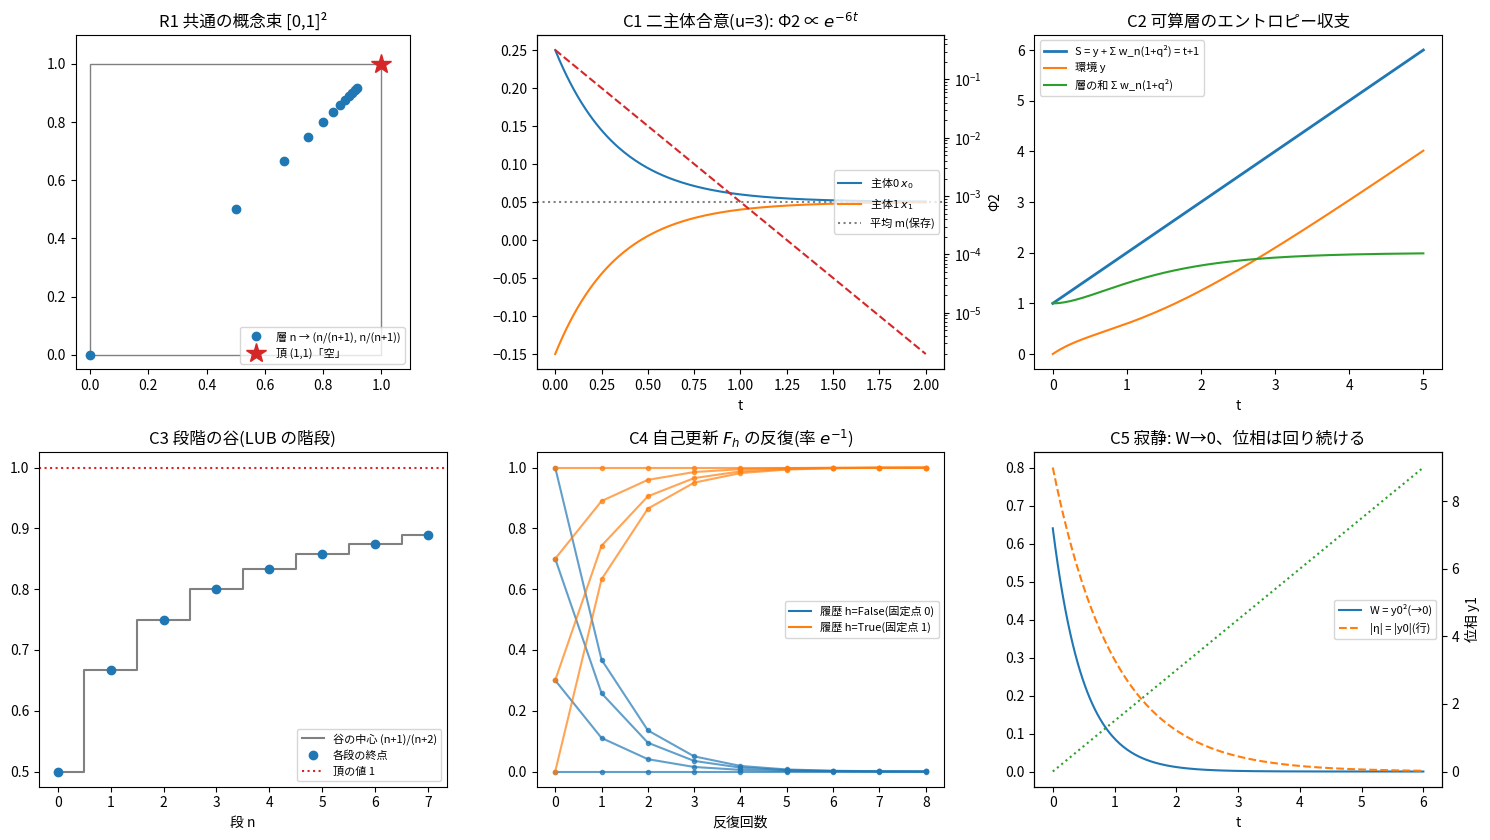

In [5]:
# %% 可視化
fig, ax = plt.subplots(2, 3, figsize=(15, 8.5))

a = ax[0, 0]                                    # R1 共通の概念束
a.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, color="gray"))
P = np.array([layer_point(n) for n in range(12)])
a.plot(P[:, 0], P[:, 1], "o", color="C0", label="層 n → (n/(n+1), n/(n+1))")
a.plot(*TOP, "*", color="C3", ms=15, label="頂 (1,1)「空」")
a.set_xlim(-0.05, 1.1); a.set_ylim(-0.05, 1.1); a.set_aspect("equal")
a.set_title("R1 共通の概念束 [0,1]²"); a.legend(loc="lower right", fontsize=8)

a = ax[0, 1]                                    # C1 合意
tt = np.linspace(0, 2, 200)
X = np.array([consensus_flow(x_init, t) for t in tt])
a.plot(tt, X[:, 0], label="主体0 $x_0$"); a.plot(tt, X[:, 1], label="主体1 $x_1$")
a.axhline(m, color="gray", ls=":", label="平均 m(保存)")
b = a.twinx()
b.semilogy(tt, [phi2(y) for y in X], "C3--", label="Φ2(対数軸)")
b.set_ylabel("Φ2")
a.set_title("C1 二主体合意(u=3): Φ2 ∝ $e^{-6t}$"); a.set_xlabel("t"); a.legend(loc="center right", fontsize=8)

a = ax[0, 2]                                    # C2 エントロピー
tt = np.linspace(0, 5, 200)
a.plot(tt, [S(t) for t in tt], lw=2, label="S = y + Σ w_n(1+q²) = t+1")
a.plot(tt, [y_env(t) for t in tt], label="環境 y")
a.plot(tt, [layer_part(t) for t in tt], label="層の和 Σ w_n(1+q²)")
a.set_title("C2 可算層のエントロピー収支"); a.set_xlabel("t"); a.legend(fontsize=8)

a = ax[1, 0]                                    # C3 段の階段(段の番号を横軸に)
nn = np.arange(8)
a.step(nn, [center(n) for n in nn], where="mid", color="gray", label="谷の中心 (n+1)/(n+2)")
a.plot(nn, stage_end, "o", color="C0", label="各段の終点")
a.axhline(1, color="C3", ls=":", label="頂の値 1")
a.set_title("C3 段階の谷(LUB の階段)"); a.set_xlabel("段 n"); a.legend(fontsize=8)

a = ax[1, 1]                                    # C4 履歴ごとの固定点
for h, ch in centers16.items():
    for x0 in (0.0, 0.3, 0.7, 1.0):
        seq = [x0]
        for _ in range(8):
            seq.append(ch + (seq[-1] - ch) * math.exp(-1.0))
        a.plot(seq, "o-", ms=3, color="C0" if not h else "C1", alpha=0.7)
a.plot([], [], "C0", label="履歴 h=False(固定点 0)"); a.plot([], [], "C1", label="履歴 h=True(固定点 1)")
a.set_title("C4 自己更新 $F_h$ の反復(率 $e^{-1}$)"); a.set_xlabel("反復回数"); a.legend(fontsize=8)

a = ax[1, 2]                                    # C5 動的寂静
tt = np.linspace(0, 6, 300)
a.plot(tt, [radius(t) ** 2 for t in tt], label="W = y0²(→0)")
a.plot(tt, [abs(radius(t)) for t in tt], "--", label="|η| = |y0|(行)")
b = a.twinx()
b.plot(tt, [phase(t) for t in tt], "C2:", label="位相 y1")
b.set_ylabel("位相 y1")
a.set_title("C5 寂静: W→0、位相は回り続ける"); a.set_xlabel("t"); a.legend(loc="center right", fontsize=8)

plt.tight_layout(); plt.show()

* **左上（共通の概念束）。** 層の点が対角線上を頂 $(1,1)$（赤い星）へ近づきます。どの有限の層も頂には届きません。
* **中上（二主体合意）。** 二人の状態（青・橙）が、平均 $m=0.05$（点線）へ両側から近づきます。平均の線は動きません。赤い破線は $\Phi_2$ を対数軸で描いたもので、**直線**（$e^{-6t}$）です。
* **右上（エントロピー収支）。** 環境 $y$（橙）と層の和（緑）はそれぞれ曲がっていますが、合計 $S$（青）は**まっすぐな直線** $t+1$ です。層の和は $1+q^2\to2$ に飽和し、残りの増加は環境が担います。
* **左下（段階の谷）。** 灰色の階段が谷の中心、青い点が各段の終点です。終点は中心にほぼ重なり（誤差は $e^{-24}$ 以下）、階段は赤い点線（頂の値 1）に近づきます。
* **中下（自己更新の反復）。** 青（履歴 False）はどこから始めても 0 へ、橙（履歴 True）は 1 へ集まります。**同じ初期値でも、履歴が違えば行き先が違います。**
* **右下（動的寂静）。** $W$（青）と $|\eta|$（橙の破線）は 0 へ向かいます。一方、位相（緑の点線、右軸）は直線で増え続けます。

## 7. 数値確認

In [6]:
# %% 数値確認
assert all(results.values()), [k for k, v in results.items() if not v]
x_X = np.array([1.3, -2.1])                     # 共通領域 X3 = {|x_i| ≤ 3} の点(θ=10 の版)
assert abs((1 + phi2(x_X, theta=10.0)) - (1 + 2 * (x_X[0] - x_X[1]) ** 2)) < 1e-12   # commonV0X
assert all(abs(center(n) - layer_point(n + 1)[0]) < 1e-15 for n in range(20))       # C3 の中心 = R1 の層の点
assert np.allclose(consensus_flow([0.1, 0.1], 1.0), [0.1, 0.1])                     # 動かない状態がある
assert not np.allclose(consensus_flow([0.2, -0.1], 1.0), [0.2, -0.1])               # 動く状態がある
print(f"全 {len(results)} 項目と共有の確認が通った(数値の確認で、証明ではない)。")

全 34 項目と共有の確認が通った(数値の確認で、証明ではない)。


* 上のセルで記録した全項目が成り立つこと。
* 共通領域 $|x_i|\le3$（閾値 $\theta=10$ の版）では、$V_0=1+2(x_0-x_1)^2$ になること（Lean の `commonV0X`）。
* C3 の段の中心と R1 の層の点が同じ数列であること。
* 動かない状態（$x_0=x_1$）と動く状態がどちらもあること（非退化性の一つ）。

## 8. 仏教的な意義（解釈）

> 原文の説明にそった**思想的な読み**で、Lean で形式化された数理結論そのものではありません。

* **教えの体系が、自分自身と食い違っていない。** 四法印（諸行無常・一切皆苦・諸法無我・涅槃寂静）と無明起行は、別々に読めばどれも成り立ちそうに見えます。しかし、ある定理のための仮定が別の定理の仮定と両立しないなら、体系全体としては成り立ちません。この結果は、**原文の前提と追加の明示条件が、一つの世界で同時に成り立ちうる**ことを示します。
* **同じ「空」の下で。** 全定理が同じ束の同じ頂（「空」）を見ています。無常（C2・C3）・苦（C5）・無我（C4）・寂静（C5）が、それぞれ別の「空」を想定しているのではありません。
* **ただし、これは「そうでありうる」ことの証明です。** 現実の心や社会がこのモデルの通りだ、と言っているのではありません。また、原文の前提**だけ**から結論が出ることも主張しません（原文の前提だけでは成り立たない反例があり、そのために追加の明示条件を置いています）。

## 9. Lean との対応

対応するディレクトリ：`Tomabechi/Consistency/`。代表の存在宣言は `ConsistencyR123_FinalV14.lean` の `final_consistency_v14`。

| 部品 | 主な Lean ファイル | 内容 | 状態 |
| --- | --- | --- | --- |
| 全体 | `ConsistencyR123_FinalV14.lean` | 原文の前提・追加の明示条件・非退化性を同時に満たす $N$ の存在 | 証明済 |
| R1 共通の概念束 | `ConsistencyR1_CommonLattice.lean` | $[0,1]^2$、層・記号・区間の順序を保つ埋め込み | 証明済 |
| C1 二主体合意系 | `ConsistencyC1_HFlow.lean`, `ConsistencyC1_Consensus.lean`, `ConsistencyC1_ConsensusControl.lean` | 全可測ゲイン信号の中で $u=3$ が最小、閉ループの流れ、定理1・2・4・20 の一般入口への適用 | 証明済 |
| R2 一点の到達 | `ConsistencyR2_PointReachability.lean` | 一点からの閉到達集合＝$x$ と $(m,m)$ を結ぶ線分 | 証明済 |
| R3 共通基礎評価 | `ConsistencyR3_CommonBase.lean` | 同じ $V_0=1+\Phi_2$ から定理1・4・20 の評価を作る | 証明済 |
| C2 エントロピー収支 | `ConsistencyC2_EntropyBalance.lean` | A1–A5・A6′・A7、H-sum、定理23第一部 | 証明済 |
| C3 段階の谷 | `ConsistencyC3_StagePresentation.lean` | 元の H-stage、定理21の四つの結論、定理19の容量、23-B | 証明済 |
| C4 自己の固定点 | `ConsistencyC4_Theorem16_25.lean`, `ConsistencyR123_CanonicalTCZ.lean` | 逆極限の縮小写像と固定点、正典 TCZ、定理25 | 証明済 |
| C5 苦・寂静・無明 | `ConsistencyC5_Theorem24_27.lean` | 同じ二層モデルで定理24・26・27 | 証明済 |

**証明していないこと・注意。**

* **単一の共有制御系ではありません。** 定理16の正典 TCZ を生成する制御系（速度制御 $\dot x=u$、$|u|\le1$）と、定理24の有界ゲイン制御系は別の系です。16 と 24 を同じ一つの制御系で実現するモデルは未構成です。
* **定理3は零平均の初期点に限ります。**
* **容量の方策族は一つです。** 定理19の容量を「問題×方策」の上限として型づけていますが、方策族は一つです。
* **定理26/27の方策族は有界可測ゲインのフィードバックに限ります**（任意の Borel フィードバックではありません）。
* **原文の前提のみから結論が導けることは主張しません。** 主張するのは、追加の明示条件を許せば同時に満たされうる、ということです。
* Python が確かめているのは、Lean で証明した等式・不等式の数値例だけです。Python の数値出力・Euler 積分（費用の比較）・試したゲイン信号の選び方は証明していません。Lean の $N$ が証明している部品間の保存式の大部分は、この notebook では扱っていません。